# Run The Inference Pipeline

This notebook runs the standard PioneerML `inference_pipeline` using the tutorial batch executor, writer, and JSONL output backend.

For a self-contained tutorial, the first cell runs the small training/export path to create a fresh local model artifact. After that, inference is config-only: model handle, batch executor, loader manager, writer, and output backend all come from the tutorial config.

> **Notebook memory:** Importing the scientific Python stack (for example PyTorch, NumPy, Matplotlib, and ZenML) can keep approximately 1 GiB of RAM assigned to this kernel for its lifetime. Python cannot safely unload native extension modules. **After finishing this tutorial, restart its kernel to clear imported libraries and release that RAM** (or shut down the kernel entirely). Restarting keeps the notebook open with a fresh, low-memory kernel. Do this before running several tutorial notebooks at once.

In [1]:
from pathlib import Path
import json
import sys
from tempfile import TemporaryDirectory

# Source-checkout bootstrap: this lets the notebook import PioneerML and the
# base plugin before either package has been installed in editable mode.
for root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    for src in (root / "src", root / "plugins" / "example_plugin" / "src"):
        if (src / "pioneerml").exists() or (src / "pioneerml_example_plugin").exists():
            src_text = str(src)
            if src_text not in sys.path:
                sys.path.insert(0, src_text)

import torch
from IPython.display import Image, display

from pioneerml.integration.zenml import utils as zenml_utils
from pioneerml.plugin import resolve_plugin

import pioneerml_example_plugin.components_tutorial_examples  # registers tutorial components
from pioneerml_example_plugin.components_tutorial_examples.pipeline import (
    inference_pipeline,
    load_config,
    training_pipeline,
    with_inference_paths,
    with_output_root,
)

PROJECT_ROOT = zenml_utils.find_project_root()
zenml_utils.setup_zenml_for_notebook(root_path=PROJECT_ROOT, use_in_memory=True)
full_config = load_config()


Using ZenML repository root: /workspace
Ensure this is the top-level of your repo (.zen must live here).


## Create A Small Model Artifact

Inference needs a model file. Rather than checking a binary checkpoint into the plugin, this setup step runs the same small training config and uses the exported state dict.

In [2]:
tmp = TemporaryDirectory(prefix="pioneerml-components-inference-")
run_root = Path(tmp.name)
training_config = with_output_root(full_config["training"], run_root)

training_run = training_pipeline.with_options(enable_cache=False)(
    pipeline_config=training_config,
)

model_candidates = sorted((run_root / "exports").glob("*_sensor_state.pt"))
if not model_candidates:
    raise RuntimeError(f"No tutorial model artifact found under {run_root / 'exports'}")
model_path = model_candidates[-1]

print(f"Setup training completed: {training_run.name}")
print(f"Model artifact: {model_path}")


Initiating a new run for the pipeline: training_pipeline.
Caching is disabled by default for training_pipeline.
Using user: default
Using stack: default
  deployer: default
  artifact_store: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step tune_model has started.


[I 2026-07-11 07:41:22,797] Using an existing study with name 'sensor_health_tutorial_bce' instead of creating a new one.


[tune_model] GPU available: True (cuda), used: False
[tune_model] TPU available: False, using: 0 TPU cores
[tune_model] /opt/conda/envs/pioneerml/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing Trainer(accelerator='gpu').



Output()

[tune_model] Trainer.fit stopped: max_epochs=25 reached.


[I 2026-07-11 07:41:28,495] Trial 5 finished with value: 0.043722014874219894 and parameters: {'hidden': 32, 'lr': 0.01086664154042655, 'batch_size_exp': 7}. Best is trial 2 with value: 0.042506683617830276.


Step tune_model has finished in 5.933s.
Step train_model has started.
[train_model] GPU available: True (cuda), used: False
[train_model] TPU available: False, using: 0 TPU cores
[train_model] /opt/conda/envs/pioneerml/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing Trainer(accelerator='gpu').



Output()

[train_model] Trainer.fit stopped: max_epochs=25 reached.


Step train_model has finished in 6.554s.
Step evaluate_model has started.
Step evaluate_model has finished in 0.364s.
Step export_model has started.
Step export_model has finished in 0.598s.
Pipeline run has finished in 14.839s.
Setup training completed: training_pipeline-2026_07_11-07_41_22_288876
Model artifact: /tmp/pioneerml-components-inference-8m_sstzg/exports/sensor_health_20260711_074136_sensor_state.pt


## Launch Inference

`with_inference_paths` updates only the runtime paths: the model handle points at the model artifact above, and the writer emits predictions into the temporary notebook output directory.

In [3]:
inference_config = with_inference_paths(
    full_config["inference"],
    model_path=model_path,
    output_root=run_root,
)

inference_run = inference_pipeline.with_options(enable_cache=False)(
    pipeline_config=inference_config,
)

prediction_path = run_root / "predictions" / "sensor_predictions.jsonl"
print(f"Inference pipeline completed: {inference_run.name}")
print(f"Status: {inference_run.status}")
print(f"Predictions: {prediction_path}")


Initiating a new run for the pipeline: inference_pipeline.
Caching is disabled by default for inference_pipeline.
Using user: default
Using stack: default
  deployer: default
  artifact_store: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step build_model_handle has started.
Step build_model_handle has finished in 0.099s.
Step run_inference has started.
Step run_inference has finished in 0.728s.
Pipeline run has finished in 1.536s.
Inference pipeline completed: inference_pipeline-2026_07_11-07_41_37_944835
Status: completed
Predictions: /tmp/pioneerml-components-inference-8m_sstzg/predictions/sensor_predictions.jsonl


## Inspect Prediction Rows

The custom writer builds an Arrow table of scores, and the custom output backend serializes it as newline-delimited JSON. Showing a few rows is enough; printing the whole pipeline response would bury the useful result.

In [4]:
prediction_rows = [json.loads(line) for line in prediction_path.read_text(encoding="utf-8").splitlines()]
print(f"Rows written: {len(prediction_rows)}")
prediction_rows[:5]


Rows written: 640


[{'event_id': 0,
  'failure_probability': 0.9998065829277039,
  'predicted_failure': 1},
 {'event_id': 1,
  'failure_probability': 0.0005317929317243397,
  'predicted_failure': 0},
 {'event_id': 2,
  'failure_probability': 0.9999997615814209,
  'predicted_failure': 1},
 {'event_id': 3,
  'failure_probability': 0.9792941212654114,
  'predicted_failure': 1},
 {'event_id': 4,
  'failure_probability': 8.687097192705551e-07,
  'predicted_failure': 0}]

## Plot Inference Scores

The inference pipeline writes probabilities. The registered `sensor_health_score_histogram` plot expects logits, so this cell converts probabilities back to logits and renders the same tutorial plot plugin against inference output.

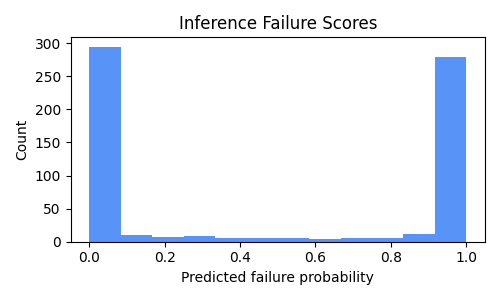

In [5]:
plot_cls = resolve_plugin(namespace="plot", name="sensor_health_score_histogram")
probs = torch.tensor([row["failure_probability"] for row in prediction_rows]).clamp(1e-6, 1 - 1e-6)
logits = torch.logit(probs).reshape(-1, 1)

inference_plot_path = run_root / "inference_score_histogram.png"
plot_cls().render(
    logits=logits,
    save_path=str(inference_plot_path),
    show=False,
    title="Inference Failure Scores",
)

display(Image(filename=str(inference_plot_path)))


## Cleanup

The temporary directory object is kept alive so the files remain available while the notebook is open. Run the next cell when you are done inspecting generated artifacts.

In [6]:
tmp.cleanup()
print("Temporary inference artifacts removed.")


Temporary inference artifacts removed.
